# Week 3 – Data Science and Visualization
## The Cleaning Sprint: Missing Values and Outlier Detection

**Dataset:** AccidentsBig.csv

### Objective
This notebook performs the data-cleaning stage of the accident-data project. It compares the dataset **before and after cleaning** so that the effect of the cleaning process can be clearly demonstrated.

### Workflow
**Raw Dataset → Before Cleaning Analysis → Missing-Value Handling → Outlier Detection → After Cleaning Analysis → Before vs After Comparison → Save Cleaned Dataset**

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Raw Dataset

In [2]:
# Load the original / uncleaned dataset

df_raw = pd.read_csv("AccidentsBig.csv", low_memory=False)

# Create a working copy for cleaning
df = df_raw.copy()

print("Raw dataset loaded successfully!")

Raw dataset loaded successfully!


## 2. BEFORE CLEANING – Dataset Representation

In [3]:
print("Rows before cleaning:", df.shape[0])
print("Columns before cleaning:", df.shape[1])
print("Shape before cleaning:", df.shape)

Rows before cleaning: 1048575
Columns before cleaning: 30
Shape before cleaning: (1048575, 30)


In [4]:
df_raw.head()

,Accident_Index,longitude,latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,Local_Authority_(District),...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Date
0,1.0,78.610393,14.724026,1.0,2.0,1.0,1.0,3.0,17:42,12.0,...,1.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,E01002849,04-01-2018
1,2.0,78.534042,14.762353,1.0,3.0,1.0,1.0,4.0,17:36,12.0,...,5.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002909,05-01-2018
2,3.0,78.470877,14.745606,1.0,3.0,2.0,1.0,5.0,00:15,12.0,...,0.0,4.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002857,06-01-2018
3,4.0,78.557994,14.667128,1.0,3.0,1.0,1.0,6.0,10:35,12.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,E01002840,07-01-2018
4,5.0,78.576431,14.703443,1.0,3.0,1.0,1.0,2.0,21:13,12.0,...,0.0,7.0,1.0,2.0,0.0,0.0,1.0,1.0,E01002863,10-01-2018


## 3. BEFORE CLEANING – Data Types

In [5]:
df_raw.dtypes

Accident_Index                                 float64
longitude                                      float64
latitude                                       float64
Police_Force                                   float64
Accident_Severity                              float64
Number_of_Vehicles                             float64
Number_of_Casualties                           float64
Day_of_Week                                    float64
Time                                            object
Local_Authority_(District)                     float64
Local_Authority_(Highway)                       object
1st_Road_Class                                 float64
1st_Road_Number                                float64
Road_Type                                      float64
Speed_limit                                    float64
Junction_Detail                                float64
Junction_Control                               float64
2nd_Road_Class                                 float64
2nd_Road_N

## 4. BEFORE CLEANING – Missing Values

In [6]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Columns containing missing values:")
print(missing_before)

Columns containing missing values:
LSOA_of_Accident_Location                      988674
Time                                           988578
Accident_Index                                 988577
Junction_Control                               988577
Did_Police_Officer_Attend_Scene_of_Accident    988577
Urban_or_Rural_Area                            988577
Carriageway_Hazards                            988577
Special_Conditions_at_Site                     988577
Road_Surface_Conditions                        988577
Weather_Conditions                             988577
Light_Conditions                               988577
Pedestrian_Crossing-Physical_Facilities        988577
Pedestrian_Crossing-Human_Control              988577
2nd_Road_Number                                988577
2nd_Road_Class                                 988577
Junction_Detail                                988577
longitude                                      988577
Speed_limit                                    

In [7]:
missing_before_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_before_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_before_pct.round(2)
}).query("`Missing Values` > 0").sort_values("Missing Values", ascending=False)

missing_before_summary

,Missing Values,Missing Percentage
LSOA_of_Accident_Location,988674,94.29
Time,988578,94.28
1st_Road_Class,988577,94.28
Number_of_Casualties,988577,94.28
latitude,988577,94.28
Weather_Conditions,988577,94.28
Urban_or_Rural_Area,988577,94.28
Speed_limit,988577,94.28
Special_Conditions_at_Site,988577,94.28
Road_Type,988577,94.28


### Observation – Before Cleaning

The raw dataset is examined before any values are changed. Missing values are identified and quantified so that appropriate treatment strategies can be selected. At this stage, no imputation or deletion is performed.

## 5. BEFORE CLEANING – Duplicate Records

In [8]:
duplicates_before = df.duplicated().sum()

print("Duplicate records before cleaning:", duplicates_before)

Duplicate records before cleaning: 988576


## 6. BEFORE CLEANING – Descriptive Statistics

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Accident_Index,59998.0,NaN,NaN,NaN,29999.5,17320.075062,1.0,15000.25,29999.5,44998.75,59998.0
longitude,59998.0,NaN,NaN,NaN,78.098483,5.949539,69.015103,73.895816,77.050768,78.544677,94.231931
latitude,59998.0,NaN,NaN,NaN,22.083749,5.65547,8.864429,18.555476,22.7328,27.091517,31.0688
Police_Force,59998.0,NaN,NaN,NaN,4.30436,4.569113,1.0,1.0,4.0,6.0,48.0
Accident_Severity,59998.0,NaN,NaN,NaN,2.855512,0.380983,1.0,3.0,3.0,3.0,3.0
Number_of_Vehicles,59998.0,NaN,NaN,NaN,1.832028,0.692804,1.0,1.0,2.0,2.0,18.0
Number_of_Casualties,59998.0,NaN,NaN,NaN,1.320761,0.762099,1.0,1.0,1.0,1.0,23.0
Day_of_Week,59998.0,NaN,NaN,NaN,4.124637,1.92369,1.0,3.0,4.0,6.0,7.0
Time,59997,1433,15:30,570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Local_Authority_(District),59998.0,NaN,NaN,NaN,71.151072,63.827188,1.0,18.0,73.0,107.0,570.0


The descriptive statistics provide a baseline for comparison with the cleaned dataset. They show the distribution, central tendency, and spread of numerical variables before cleaning.

## 7. Missing-Value Visualization – Before Cleaning

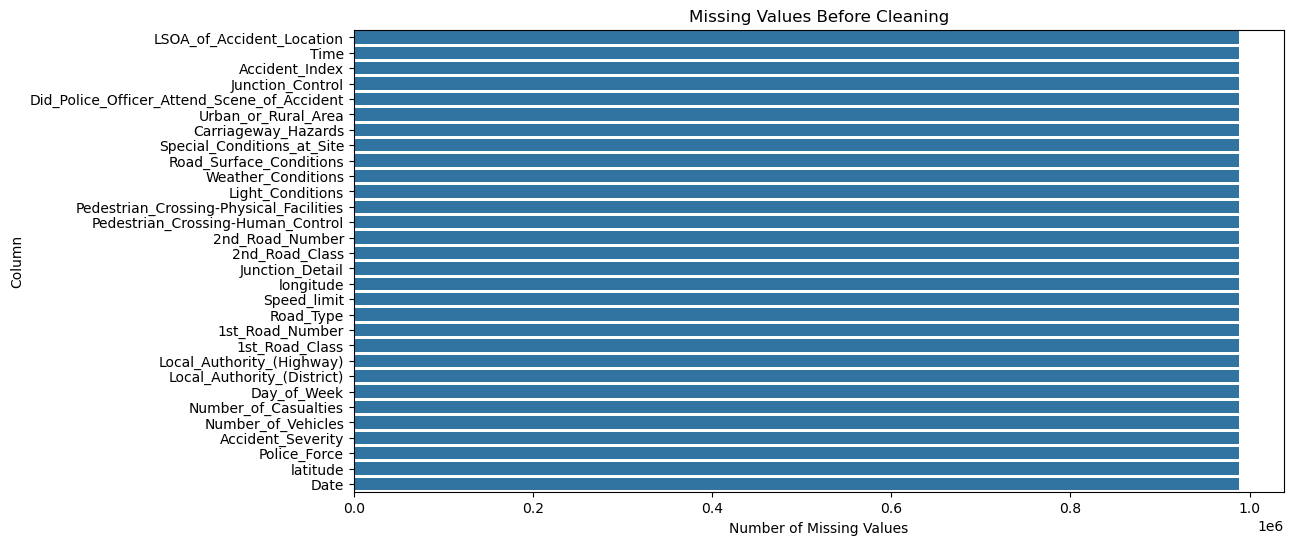

In [10]:
plt.figure(figsize=(12, 6))

missing_plot = df.isnull().sum()
missing_plot = missing_plot[missing_plot > 0].sort_values(ascending=False)

if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.values, y=missing_plot.index)
    plt.title("Missing Values Before Cleaning")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Column")
    plt.show()
else:
    print("No missing values found.")

## 8. Select Numerical and Categorical Columns

In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 26
Number of categorical columns: 4


## 9. Missing Value Handling

### 9.1 Numerical Columns – Median Imputation

Median imputation is used for numerical columns containing missing values. The median is less sensitive to extreme values than the mean and is therefore useful when numerical variables may contain skewed observations.

In [12]:
# Store missing-value counts before imputation
missing_num_before = df[numerical_columns].isnull().sum()

for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Numerical missing values after median imputation:")
print(df[numerical_columns].isnull().sum().sum())

Numerical missing values after median imputation:
0


### 9.2 Categorical Columns – Mode Imputation

Mode imputation is used for categorical columns containing missing values. The mode is the most frequently occurring category.

In [13]:
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode(dropna=True)
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value.iloc[0])

print("Categorical missing values after mode imputation:")
print(df[categorical_columns].isnull().sum().sum())

Categorical missing values after mode imputation:
0


### 9.3 Recheck Missing Values

The dataset is checked again after imputation. Any columns that still contain missing values are displayed for further consideration.

In [14]:
missing_after_imputation = df.isnull().sum()
missing_after_imputation = missing_after_imputation[missing_after_imputation > 0].sort_values(ascending=False)

if len(missing_after_imputation) == 0:
    print("No missing values remain after imputation.")
else:
    print("Columns still containing missing values:")
    print(missing_after_imputation)

No missing values remain after imputation.


## 10. Outlier Detection Using Boxplots

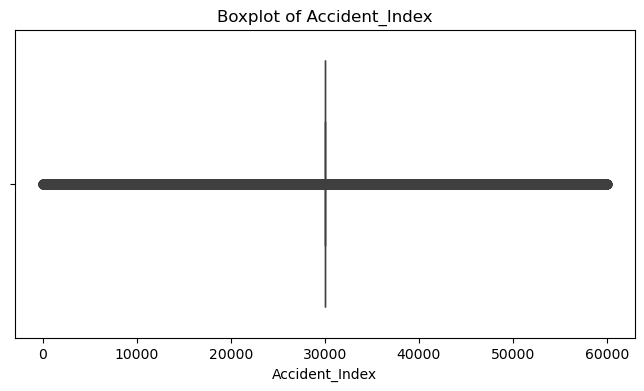

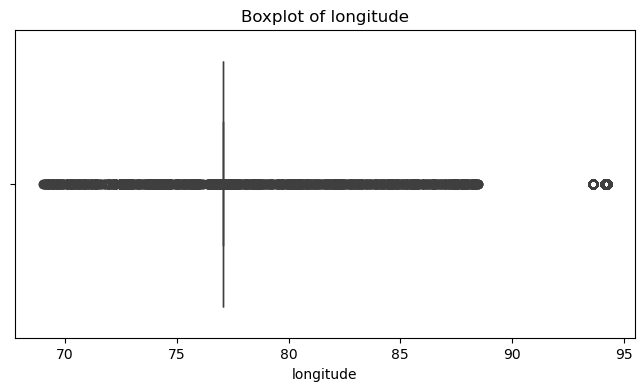

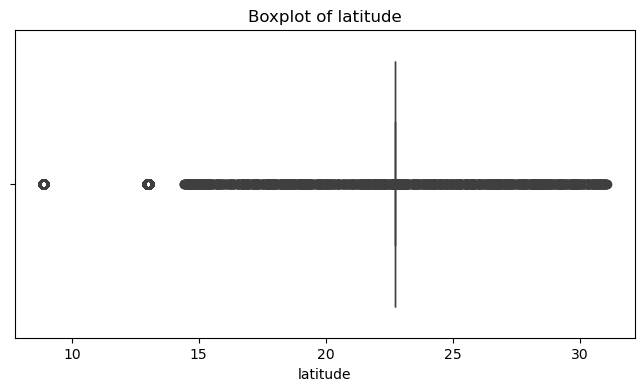

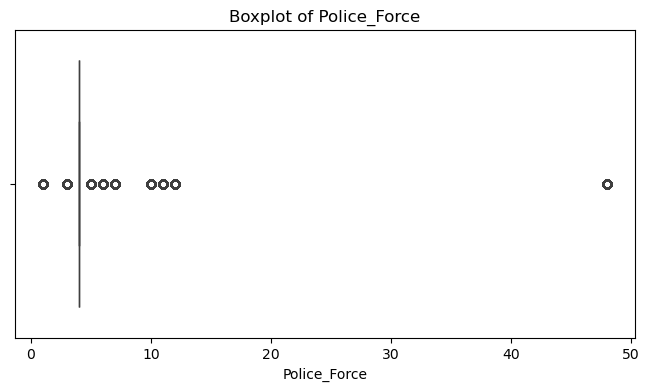

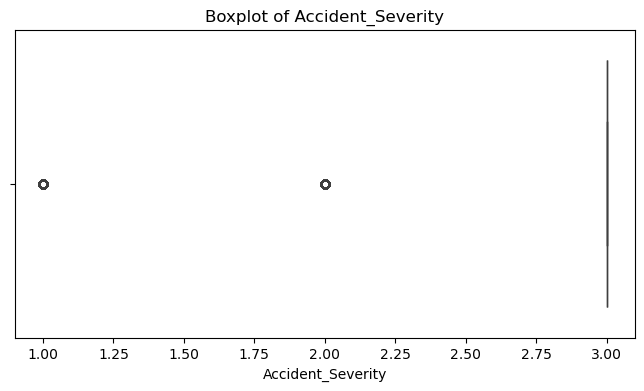

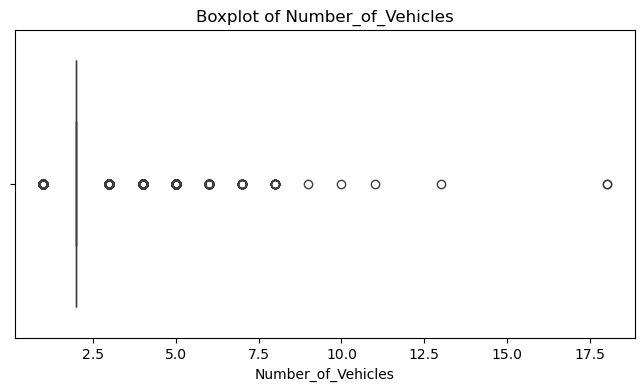

In [15]:
# Select up to 6 numerical columns for a clear visual comparison
plot_columns = numerical_columns[:6]

for col in plot_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Observation

Boxplots help identify observations that lie outside the whiskers and may therefore be potential outliers. A potential outlier is not automatically an error, so the observations should be interpreted in the context of the accident dataset.

## 11. Outlier Detection Using Z-score

In [16]:
# Z-score analysis is performed only on numerical columns
z_scores = df[numerical_columns].apply(zscore, nan_policy="omit")

outlier_counts = (z_scores.abs() > 3).sum()
outlier_percentages = (outlier_counts / len(df)) * 100

outlier_summary = pd.DataFrame({
    "Potential Outliers": outlier_counts,
    "Percentage": outlier_percentages.round(2)
}).sort_values("Potential Outliers", ascending=False)

outlier_summary

,Potential Outliers,Percentage
Junction_Detail,37464,3.57
Accident_Index,35140,3.35
Local_Authority_(District),34139,3.26
latitude,34041,3.25
Day_of_Week,32891,3.14
Number_of_Vehicles,23628,2.25
1st_Road_Class,22757,2.17
2nd_Road_Class,20141,1.92
Junction_Control,19966,1.90
Light_Conditions,16818,1.60


### Interpretation

Using the commonly applied threshold **|Z| > 3**, observations beyond three standard deviations from the mean are flagged as potential outliers.

The purpose of this step is detection and assessment. Potential outliers are retained unless there is sufficient evidence that they represent incorrect or invalid data.

## 12. AFTER CLEANING – Missing Values

In [17]:
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

if len(missing_after) == 0:
    print("No missing values remain in the dataset.")
else:
    print(missing_after)

No missing values remain in the dataset.


## 13. AFTER CLEANING – Duplicate Records

In [18]:
duplicates_after = df.duplicated().sum()

print("Duplicate records after cleaning:", duplicates_after)

Duplicate records after cleaning: 988576


## 14. AFTER CLEANING – Dataset Shape

In [19]:
print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])
print("Shape after cleaning:", df.shape)

Rows after cleaning: 1048575
Columns after cleaning: 30
Shape after cleaning: (1048575, 30)


## 15. AFTER CLEANING – Descriptive Statistics

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accident_Index,1048575.0,29999.500000,4143.000588,1.000000,29999.500000,29999.500000,29999.500000,59998.000000
longitude,1048575.0,77.110717,1.443798,69.015103,77.050768,77.050768,77.050768,94.231931
latitude,1048575.0,22.695662,1.361174,8.864429,22.732800,22.732800,22.732800,31.068800
Police_Force,1048575.0,4.017415,1.095226,1.000000,4.000000,4.000000,4.000000,48.000000
Accident_Severity,1048575.0,2.991733,0.097114,1.000000,3.000000,3.000000,3.000000,3.000000
Number_of_Vehicles,1048575.0,1.990389,0.170250,1.000000,2.000000,2.000000,2.000000,18.000000
Number_of_Casualties,1048575.0,1.018353,0.196931,1.000000,1.000000,1.000000,1.000000,23.000000
Day_of_Week,1048575.0,4.007132,0.461061,1.000000,4.000000,4.000000,4.000000,7.000000
Local_Authority_(District),1048575.0,72.894207,15.273644,1.000000,73.000000,73.000000,73.000000,570.000000
1st_Road_Class,1048575.0,3.056199,0.397498,1.000000,3.000000,3.000000,3.000000,6.000000


## 16. BEFORE vs AFTER – Missing Values

In [21]:
before_total_missing = int(df_raw.isnull().sum().sum())
after_total_missing = int(df.isnull().sum().sum())

comparison_missing = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning"],
    "Total Missing Values": [before_total_missing, after_total_missing]
})

comparison_missing

,Stage,Total Missing Values
0,Before Cleaning,29657408
1,After Cleaning,0


## 17. BEFORE vs AFTER – Duplicate Records

In [22]:
comparison_duplicates = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning"],
    "Duplicate Records": [duplicates_before, duplicates_after]
})

comparison_duplicates

,Stage,Duplicate Records
0,Before Cleaning,988576
1,After Cleaning,988576


## 18. BEFORE vs AFTER – Dataset Dimensions

In [23]:
comparison_shape = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning"],
    "Rows": [df_raw.shape[0], df.shape[0]],
    "Columns": [df_raw.shape[1], df.shape[1]]
})

comparison_shape

,Stage,Rows,Columns
0,Before Cleaning,1048575,30
1,After Cleaning,1048575,30


## 19. Before vs After Missing-Value Visualization

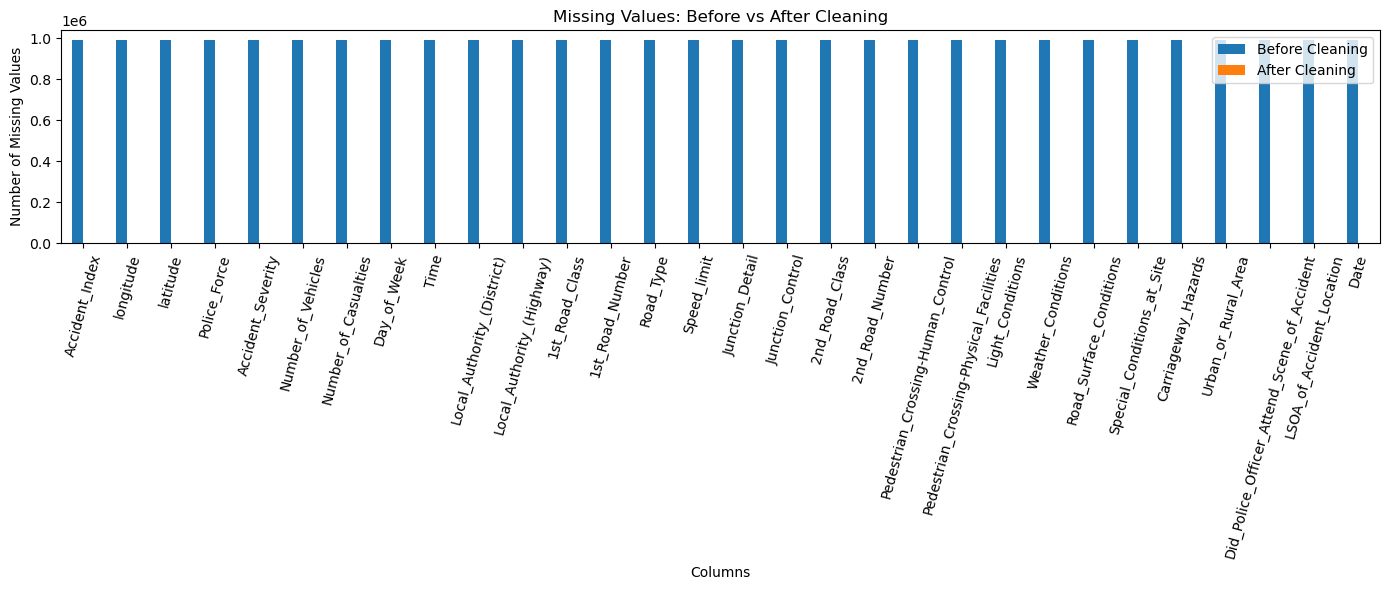

In [24]:
before_counts = df_raw.isnull().sum()
after_counts = df.isnull().sum()

comparison = pd.DataFrame({
    "Before Cleaning": before_counts,
    "After Cleaning": after_counts
})

comparison = comparison[(comparison["Before Cleaning"] > 0) | (comparison["After Cleaning"] > 0)]

if len(comparison) > 0:
    comparison.plot(kind="bar", figsize=(14, 6))
    plt.title("Missing Values: Before vs After Cleaning")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=75)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values available for comparison.")

### Before vs After Observation

The comparison clearly shows the effect of the missing-value treatment. The number of missing values after cleaning should be lower than or equal to the number observed in the raw dataset. Numerical missing values were handled using median imputation and categorical missing values using mode imputation.

## 20. Save the Cleaned Dataset

In [25]:
output_file = "AccidentsBig_cleaned_week3.csv"

df.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")

Cleaned dataset saved as: AccidentsBig_cleaned_week3.csv


## 21. Final Verification

In [26]:
print("Final shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate records:", df.duplicated().sum())

Final shape: (1048575, 30)
Total missing values: 0
Duplicate records: 988576


## 22. Conclusion

Week 3 focused on cleaning and validating the accident dataset. The raw dataset was first analyzed to establish a baseline for missing values, duplicates, data types, dimensions, and descriptive statistics.

Missing values in numerical columns were handled using median imputation, while categorical columns were handled using mode imputation. Outliers were investigated using boxplots and Z-score analysis. Potential outliers were identified for assessment rather than automatically removed, since unusual accident-related observations may represent legitimate records.

Finally, the cleaned dataset was compared with the original dataset using missing-value counts, duplicate counts, dataset dimensions, and visual comparison. The cleaned dataset was saved as `AccidentsBig_cleaned_week3.csv` for use in later project stages.

## Project Status

**Week 3: Missing Value Handling, Outlier Detection, and Before-vs-After Cleaning Analysis — Completed**